# Director Skill Sets Table 7 - Cessation only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm = pd.read_pickle(rf"{import_folder_path}\Director Level_FF3_CAR.pkl")
dirFirm = dirFirm.loc[ dirFirm["date_source"] == "Cessation Date"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")

# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [4]:
dirFirm

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

In [5]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log(dirFirm["CompCountOtherPastTotalAB"] + 1).astype("float")

In [6]:
dirFirm.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_SMB,OLS120_HML,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_SMB,OLS150_HML,OLS150_r_squared,OLS150_adjusted_r_squared,OLS15

# PSM

## Verifying and removing those rows with no control data points

In [7]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
dirFirm.columns.to_list()

['index',
 'Symbol',
 'Company',
 'AsOnDate',
 'AsOnYear',
 'ISIN',
 'Person Code',
 'Director Salutation',
 'Director First Name',
 'Director Middle Name',
 'Director Surname',
 'Date of Birth',
 'Gender',
 'Nationality',
 'Member of Civil Services',
 'Promoter Director (Yes/No)',
 'Position on Board',
 'Independent (Yes/No)',
 'Education1',
 'Education2',
 'Education3',
 'Education4',
 'Education5',
 'Education6',
 'Education7',
 'Education8',
 'Education9',
 'Education10',
 'Skills/Competencies',
 'Occupation',
 'Cessation Reason',
 'Other Directorship 1',
 'Other Directorship 2',
 'Other Directorship 3',
 'Other Directorship 4',
 'Other Directorship 5',
 'Other Directorship 6',
 'Other Directorship 7',
 'Other Directorship 8',
 'Other Directorship 9',
 'Other Directorship 10',
 'Other Directorship 11',
 'Other Directorship 12',
 'Other Directorship 13',
 'Other Directorship 14',
 'Other Directorship 15',
 'Brief Profile',
 'Tenure Valid till',
 'Date of Demise',
 'Indep',
 'Appoint

In [8]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


# dirFirm["NIC_2digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:2])
# dirFirm["NIC_2digit"] = dirFirm["NIC_2digit"]

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013)].copy()
# \
# & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
#psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
#psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count         8054.000000            8054.000000
mean             0.021120               0.019310
std              1.919772               1.920044
min             -0.129012              -1.037300
25%             -0.036444              -0.036444
50%             -0.004650              -0.004650
75%              0.029590               0.029590
max            172.195616             172.195616


Top values and their count:  nonwinsorised_120CAR3
0.356171      1
0.367948      1
0.431175      1
0.458703      3
0.477541      1
0.486351      2
0.533764      1
0.554026      1
0.586782      1
172.195616    1
Name: count, dtype: int64





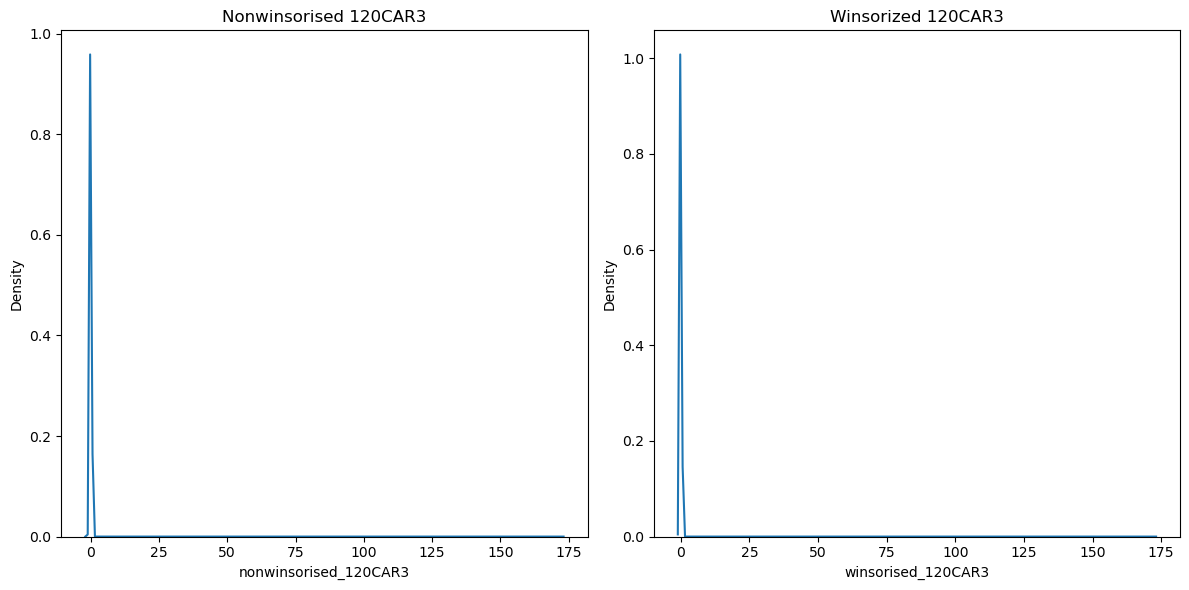

       winsorised_120CAR5  nonwinsorised_120CAR5
count         8054.000000            8054.000000
mean            -0.027704              -0.030055
std              1.920842               1.921277
min             -0.214296              -1.462671
25%             -0.094520              -0.094520
50%             -0.053927              -0.053927
75%             -0.014081              -0.014081
max            172.160588             172.160588


Top values and their count:  nonwinsorised_120CAR5
0.532473      2
0.535876      1
0.594632      1
0.624013      1
0.636798      1
0.722034      2
0.845454      1
0.851770      1
1.445203      2
172.160588    1
Name: count, dtype: int64





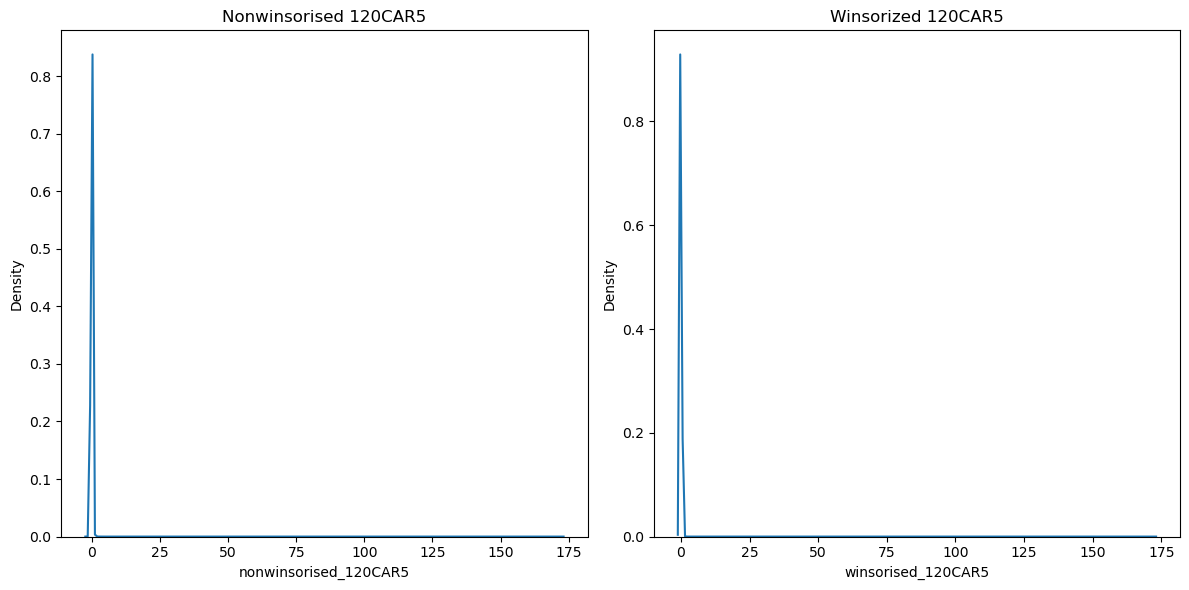

       winsorised_120CAR7  nonwinsorised_120CAR7
count         8049.000000            8049.000000
mean            -0.076111              -0.078638
std              1.922687               1.923200
min             -0.296357              -1.847159
25%             -0.154120              -0.154120
50%             -0.103345              -0.103345
75%             -0.053081              -0.053081
max            172.142157             172.142157


Top values and their count:  nonwinsorised_120CAR7
0.537919      3
0.582257      2
0.610291      1
0.628942      1
0.706554      1
0.878482      2
1.018668      2
1.338337      1
1.637965      1
172.142157    1
Name: count, dtype: int64





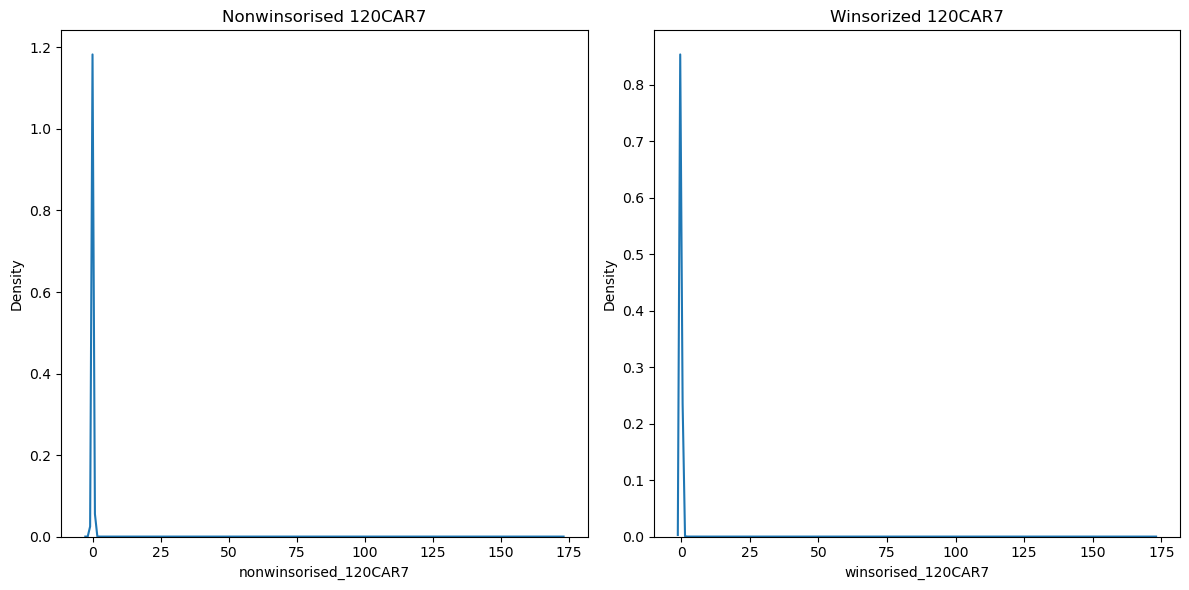

       winsorised_120CAR11  nonwinsorised_120CAR11
count          8048.000000             8048.000000
mean             -0.172397               -0.175928
std               1.925998                1.927026
min              -0.457117               -2.979978
25%              -0.273119               -0.273119
50%              -0.204059               -0.204059
75%              -0.132183               -0.132183
max             172.003758              172.003758


Top values and their count:  nonwinsorised_120CAR11
0.669056      1
0.731454      1
0.938677      2
0.959785      1
1.158457      1
1.224999      1
2.020538      1
2.313105      2
5.841753      1
172.003758    1
Name: count, dtype: int64





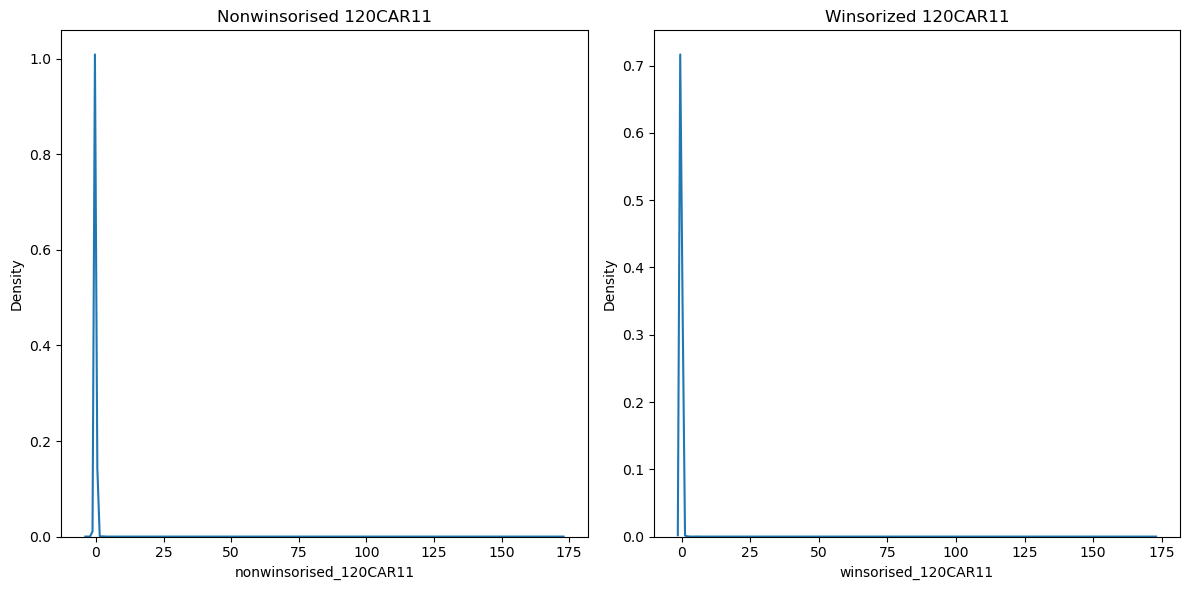

       winsorised_150CAR3  nonwinsorised_150CAR3
count         8034.000000            8034.000000
mean             0.021315               0.019571
std              1.922150               1.922392
min             -0.126340              -0.767931
25%             -0.035971              -0.035971
50%             -0.005207              -0.005207
75%              0.029682               0.029682
max            172.195933             172.195933


Top values and their count:  nonwinsorised_150CAR3
0.347457      2
0.428833      1
0.432583      1
0.464732      2
0.466824      3
0.468911      1
0.531037      1
0.567501      1
0.589509      1
172.195933    1
Name: count, dtype: int64





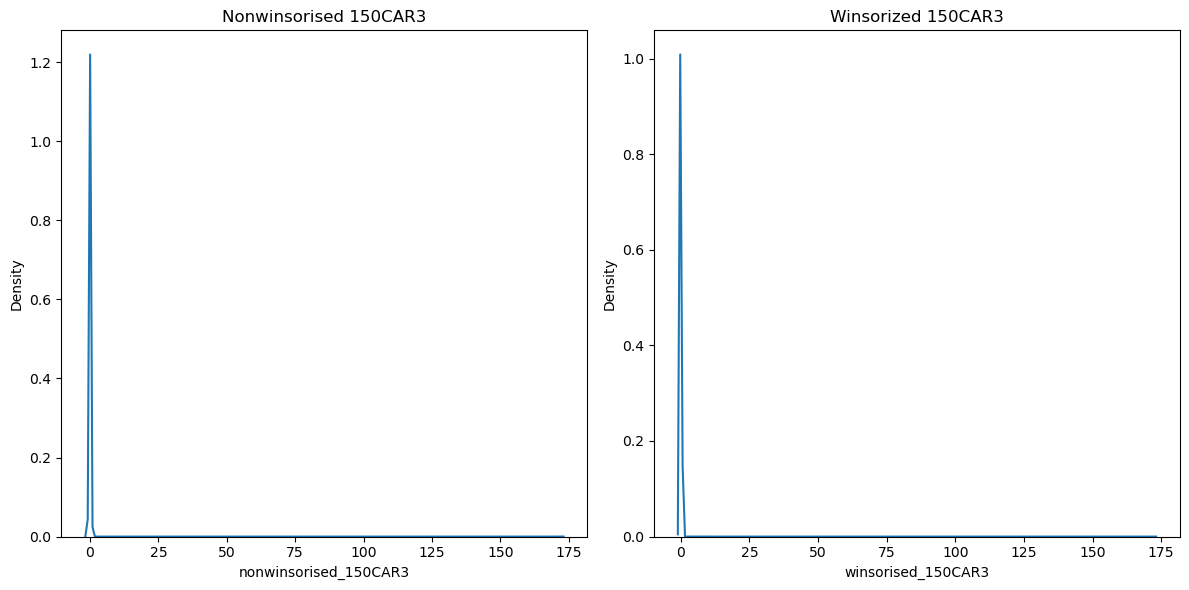

       winsorised_150CAR5  nonwinsorised_150CAR5
count         8034.000000            8034.000000
mean            -0.027694              -0.029891
std              1.923230               1.923619
min             -0.214072              -1.175801
25%             -0.093573              -0.093573
50%             -0.054218              -0.054218
75%             -0.014420              -0.014420
max            172.160930             172.160930


Top values and their count:  nonwinsorised_150CAR5
0.530802      1
0.539434      2
0.598704      1
0.621885      1
0.692687      1
0.707051      2
0.852672      1
0.931360      1
1.421520      2
172.160930    1
Name: count, dtype: int64





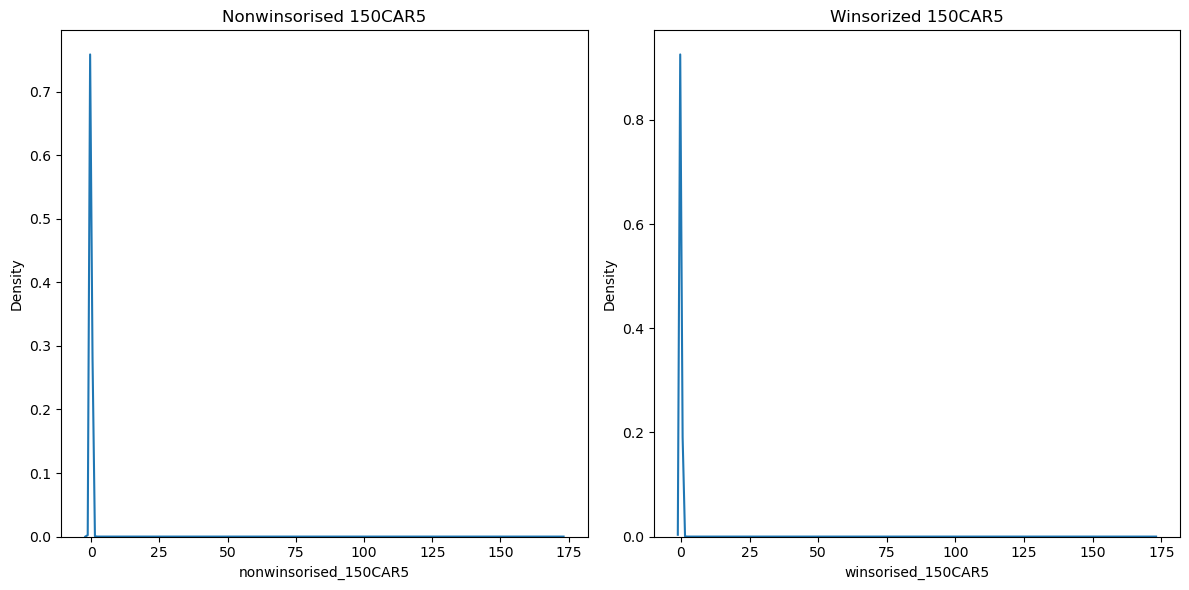

       winsorised_150CAR7  nonwinsorised_150CAR7
count         8029.000000            8029.000000
mean            -0.076334              -0.078699
std              1.925050               1.925510
min             -0.297257              -1.559946
25%             -0.155370              -0.155370
50%             -0.103637              -0.103637
75%             -0.053436              -0.053436
max            172.142176             172.142176


Top values and their count:  nonwinsorised_150CAR7
0.574693      2
0.587675      1
0.623858      1
0.627795      1
0.696607      1
0.777151      2
0.868898      2
1.340499      1
1.641332      1
172.142176    1
Name: count, dtype: int64





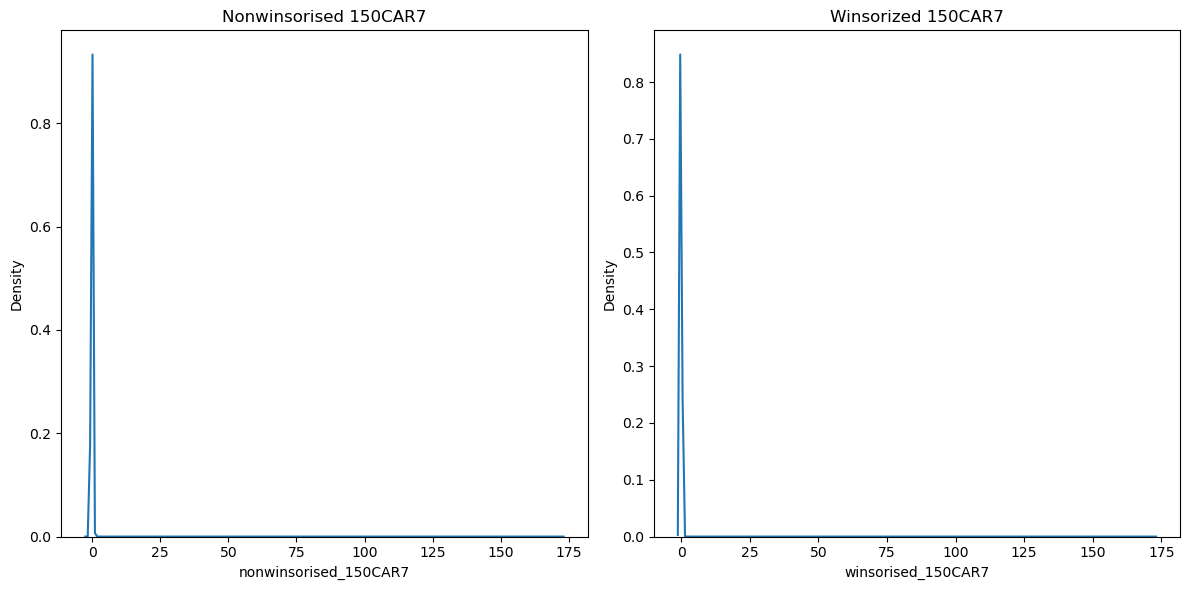

       winsorised_150CAR11  nonwinsorised_150CAR11
count          8028.000000             8028.000000
mean             -0.173086               -0.176380
std               1.928226                1.929132
min              -0.459522               -2.542102
25%              -0.274179               -0.274179
50%              -0.204518               -0.204518
75%              -0.131758               -0.131758
max             172.003660              172.003660


Top values and their count:  nonwinsorised_150CAR11
0.680135      1
0.731627      1
0.854179      2
0.975171      1
1.161769      1
1.326542      1
1.892436      2
2.023445      1
5.826507      1
172.003660    1
Name: count, dtype: int64





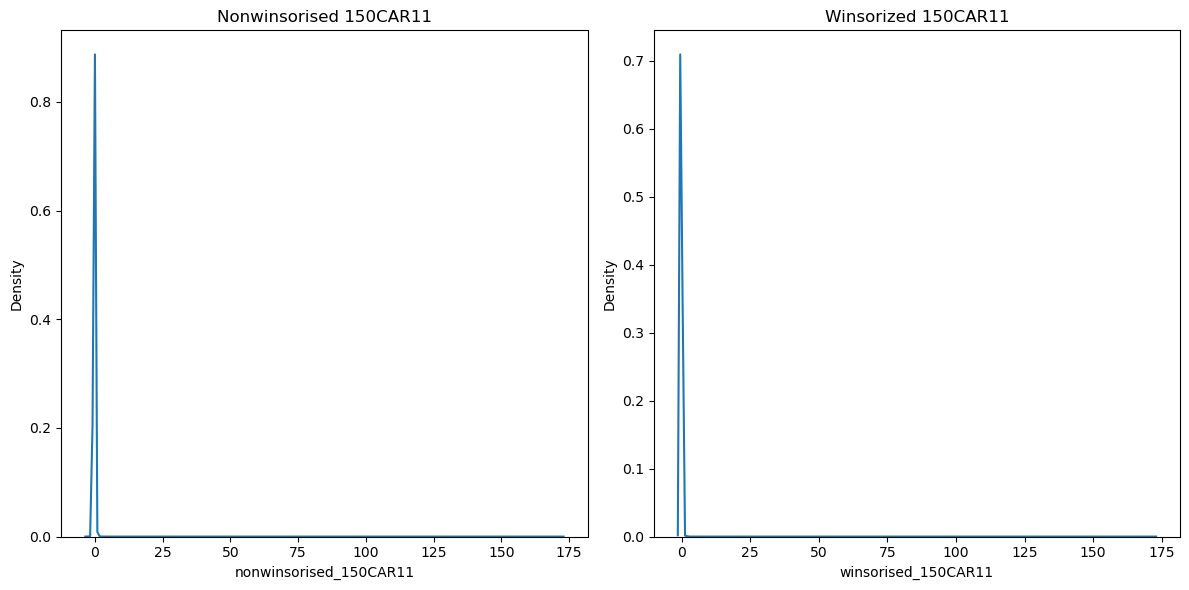

       winsorised_180CAR3  nonwinsorised_180CAR3
count         8004.000000            8004.000000
mean             0.021065               0.019304
std              1.925771               1.926004
min             -0.126761              -0.695642
25%             -0.036403              -0.036403
50%             -0.005356              -0.005356
75%              0.029518               0.029518
max            172.197025             172.197025


Top values and their count:  nonwinsorised_180CAR3
0.343946      1
0.420811      1
0.434575      1
0.471489      1
0.473990      3
0.488314      2
0.535148      1
0.593403      1
0.597871      1
172.197025    1
Name: count, dtype: int64





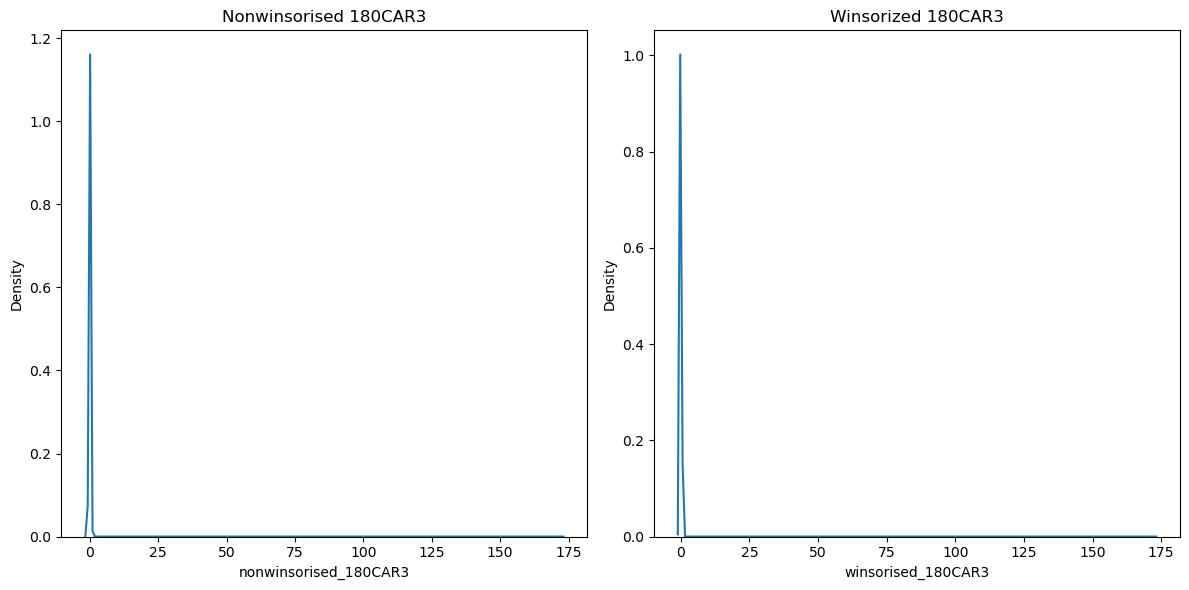

       winsorised_180CAR5  nonwinsorised_180CAR5
count         8004.000000            8004.000000
mean            -0.028159              -0.030245
std              1.926872               1.927232
min             -0.218054              -0.981951
25%             -0.094771              -0.094771
50%             -0.054854              -0.054854
75%             -0.014665              -0.014665
max            172.161940             172.161940


Top values and their count:  nonwinsorised_180CAR5
0.504668      1
0.534560      1
0.625080      1
0.673504      1
0.715774      1
0.750899      2
0.860962      1
0.917677      1
1.450691      2
172.161940    1
Name: count, dtype: int64





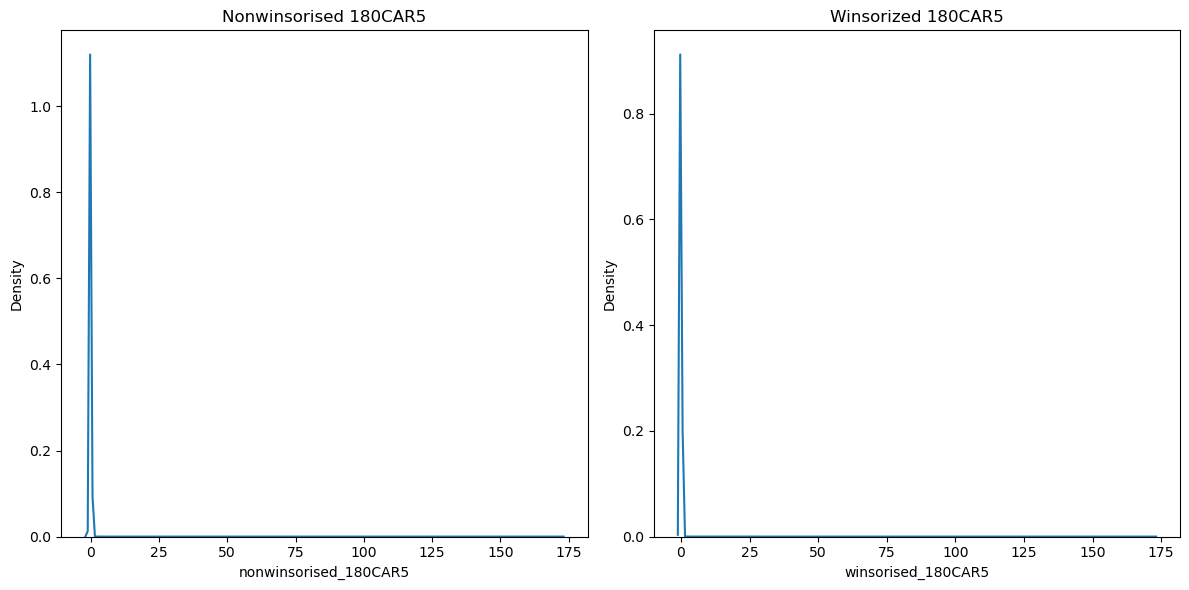

       winsorised_180CAR7  nonwinsorised_180CAR7
count         7999.000000            7999.000000
mean            -0.076565              -0.078855
std              1.928723               1.929153
min             -0.299435              -1.305520
25%             -0.155708              -0.155708
50%             -0.103741              -0.103741
75%             -0.053403              -0.053403
max            172.142544             172.142544


Top values and their count:  nonwinsorised_180CAR7
0.576599      2
0.601671      1
0.622758      1
0.659249      1
0.697917      1
0.893259      2
1.027776      2
1.344630      1
1.694966      1
172.142544    1
Name: count, dtype: int64





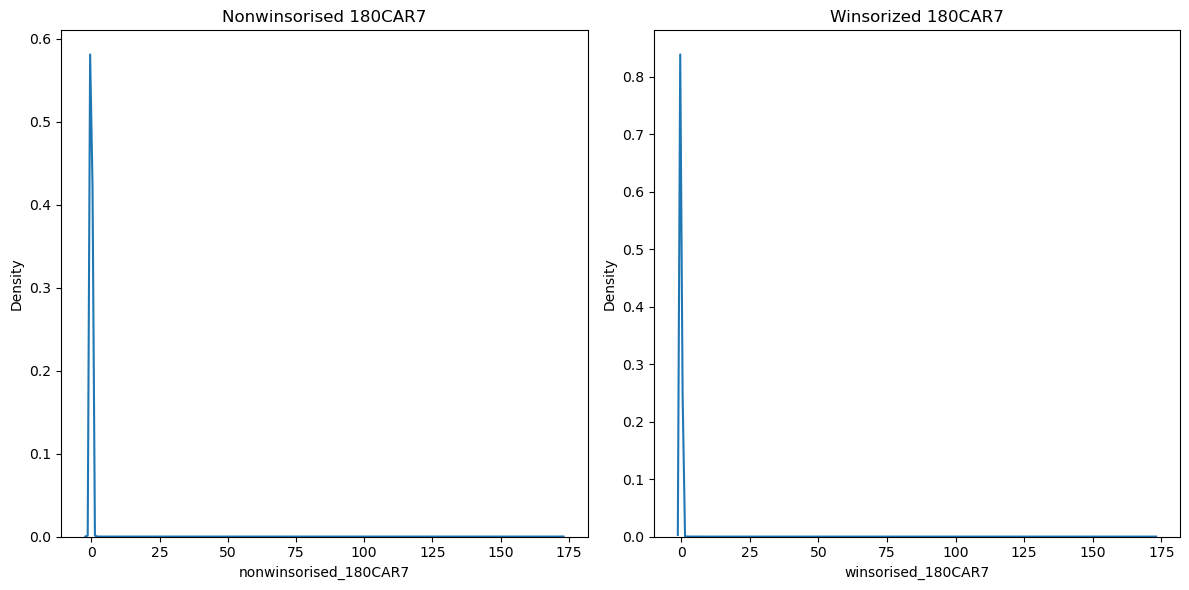

       winsorised_180CAR11  nonwinsorised_180CAR11
count          7998.000000             7998.000000
mean             -0.172887               -0.176105
std               1.932027                1.932858
min              -0.458928               -2.098553
25%              -0.273666               -0.273666
50%              -0.205177               -0.205177
75%              -0.133161               -0.133161
max             172.003280              172.003280


Top values and their count:  nonwinsorised_180CAR11
0.709277      1
0.731233      1
0.926114      2
1.020993      1
1.198482      1
1.329517      1
2.028564      1
2.373080      2
5.816717      1
172.003280    1
Name: count, dtype: int64





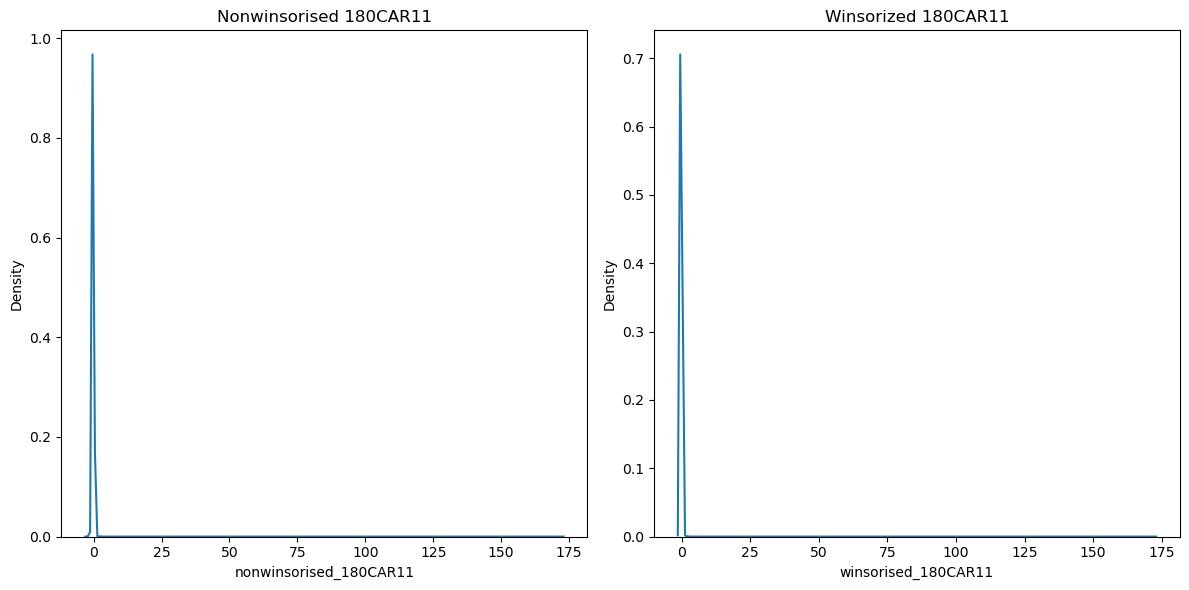

       winsorised_210CAR3  nonwinsorised_210CAR3
count         7975.000000            7975.000000
mean             0.021240               0.019415
std              1.929248               1.929512
min             -0.128026              -1.156987
25%             -0.036466              -0.036466
50%             -0.004904              -0.004904
75%              0.029985               0.029985
max            172.195045             172.195045


Top values and their count:  nonwinsorised_210CAR3
0.346333      2
0.395621      1
0.432727      1
0.475898      3
0.477187      1
0.483847      2
0.531654      1
0.592347      1
0.610097      1
172.195045    1
Name: count, dtype: int64





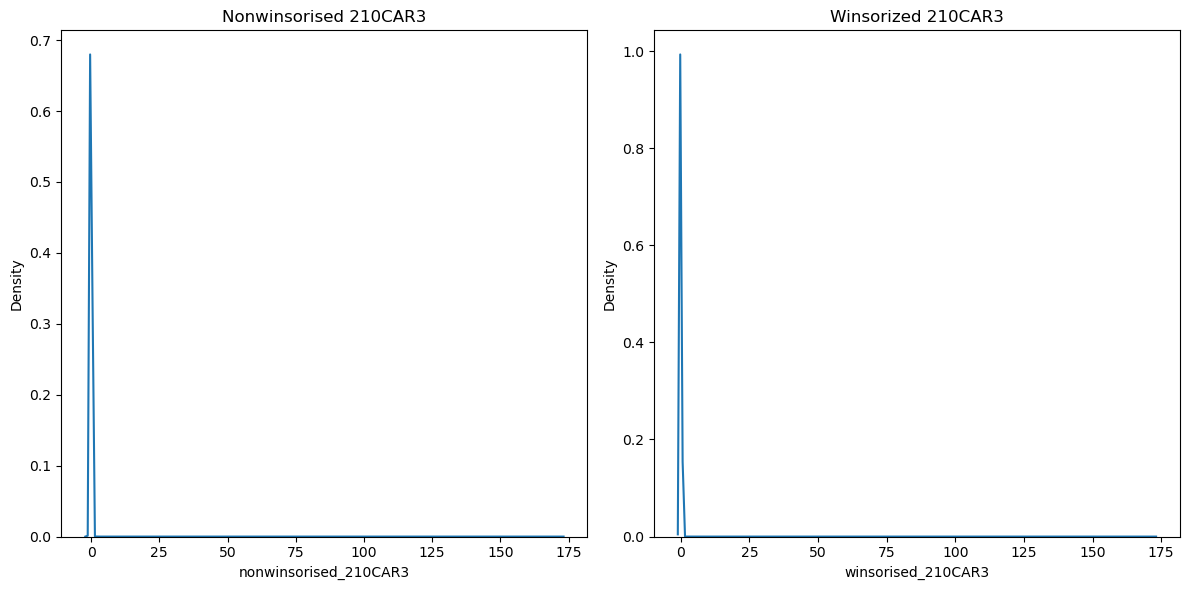

       winsorised_210CAR5  nonwinsorised_210CAR5
count         7975.000000            7975.000000
mean            -0.027997              -0.030182
std              1.930358               1.930759
min             -0.220135              -1.322327
25%             -0.093808              -0.093808
50%             -0.054642              -0.054642
75%             -0.015063              -0.015063
max            172.160364             172.160364


Top values and their count:  nonwinsorised_210CAR5
0.532465      2
0.532976      1
0.615843      1
0.704300      1
0.737757      1
0.742416      2
0.861614      1
0.885041      1
1.449875      2
172.160364    1
Name: count, dtype: int64





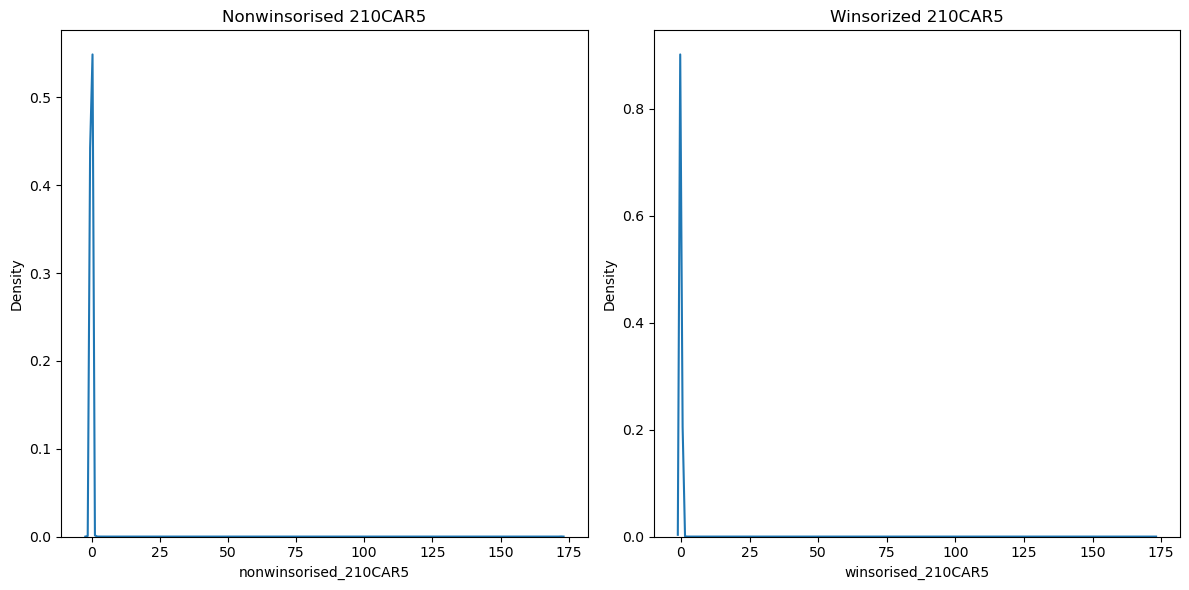

       winsorised_210CAR7  nonwinsorised_210CAR7
count         7970.000000            7970.000000
mean            -0.076517              -0.079023
std              1.932219               1.932721
min             -0.298420              -1.660867
25%             -0.155765              -0.155765
50%             -0.103517              -0.103517
75%             -0.054133              -0.054133
max            172.142646             172.142646


Top values and their count:  nonwinsorised_210CAR7
0.575180      2
0.576644      1
0.623038      1
0.694031      1
0.694186      1
0.900406      2
1.076781      2
1.342183      1
1.707762      1
172.142646    1
Name: count, dtype: int64





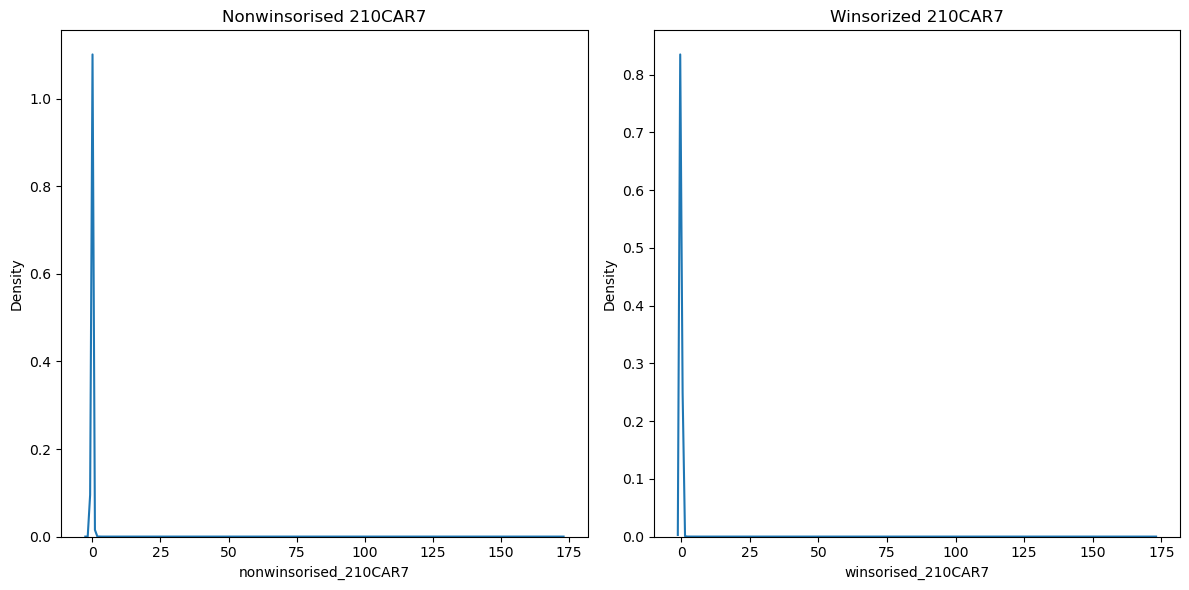

       winsorised_210CAR11  nonwinsorised_210CAR11
count          7969.000000             7969.000000
mean             -0.172771               -0.176027
std               1.935542                1.936358
min              -0.459283               -1.685227
25%              -0.272906               -0.272906
50%              -0.204916               -0.204916
75%              -0.133205               -0.133205
max             172.003609              172.003609


Top values and their count:  nonwinsorised_210CAR11
0.704025      1
0.731207      1
0.900506      2
1.145340      1
1.197564      1
1.249906      1
2.025149      1
2.483369      2
5.814373      1
172.003609    1
Name: count, dtype: int64





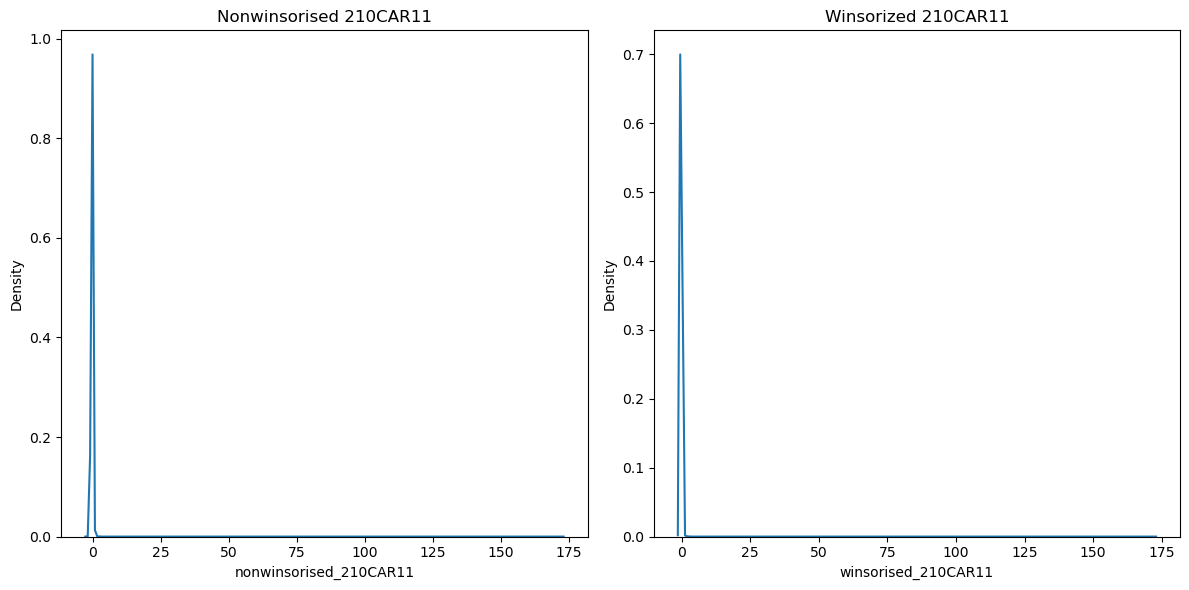

In [9]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0.01, 0.01])

In [10]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [11]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [12]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment":<20}{"Control":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [13]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [14]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [15]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [16]:
psmSampleIndep

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

# CAR Plots

### Total Sample

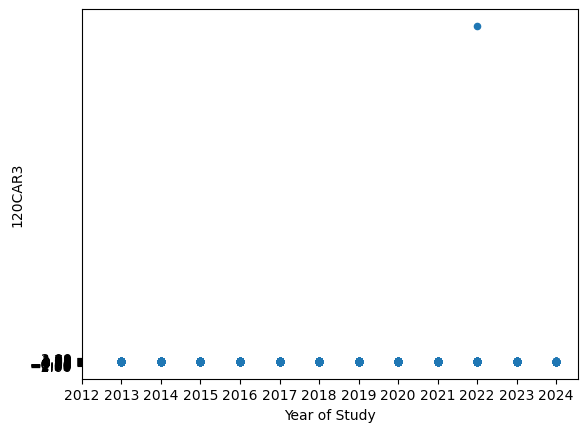

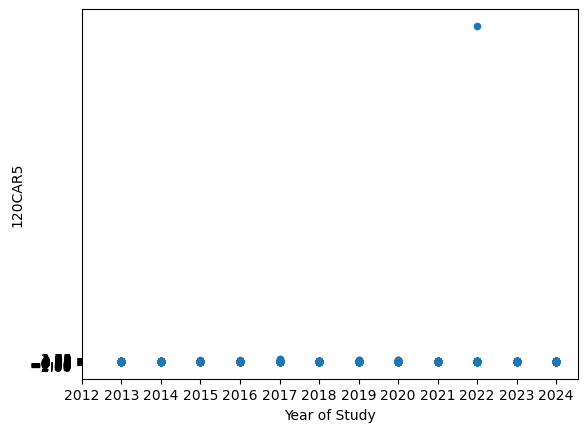

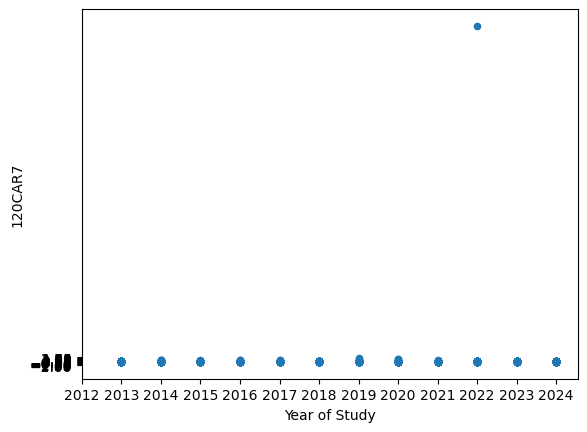

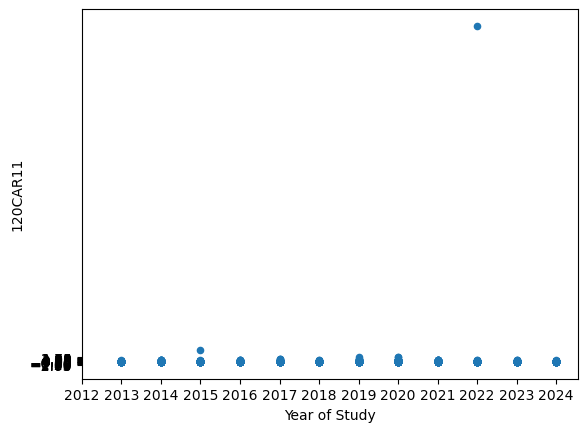

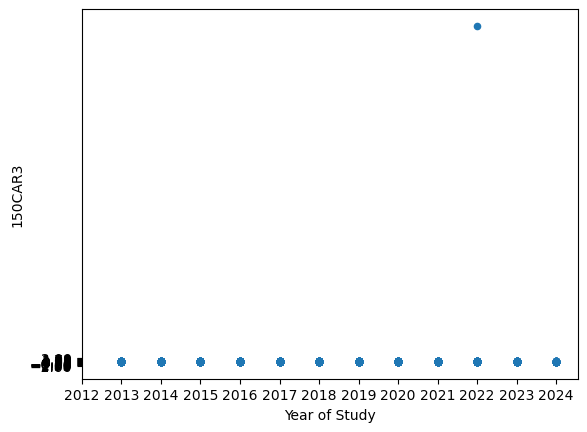

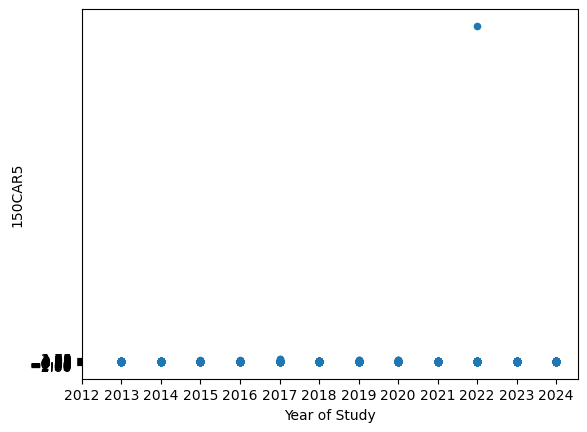

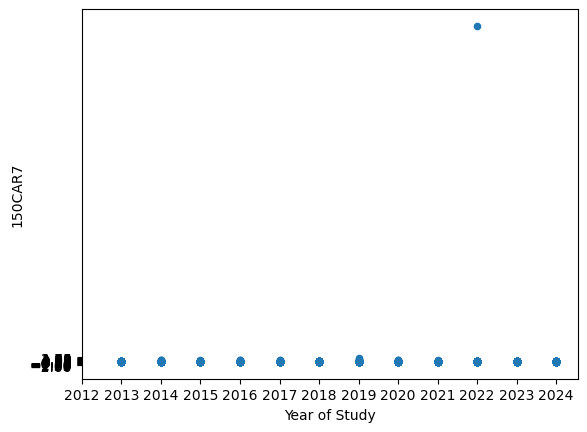

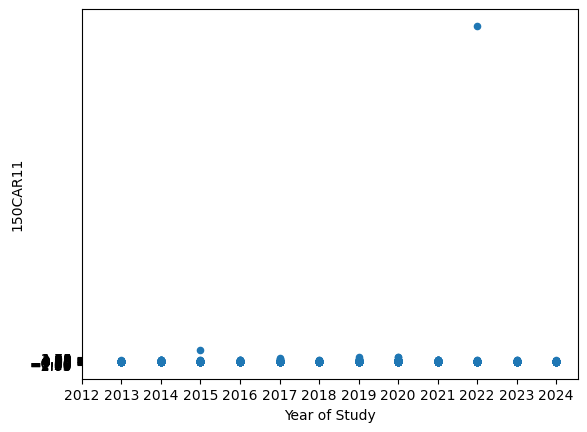

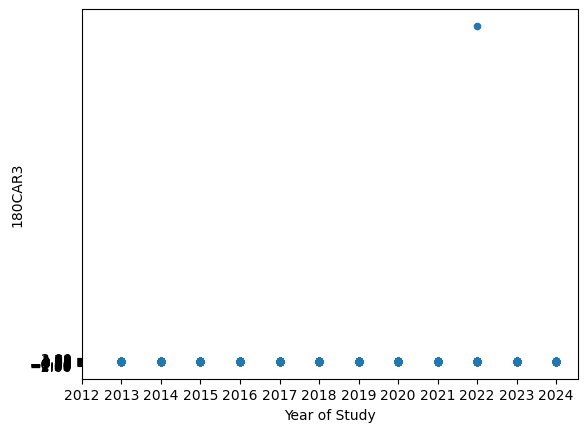

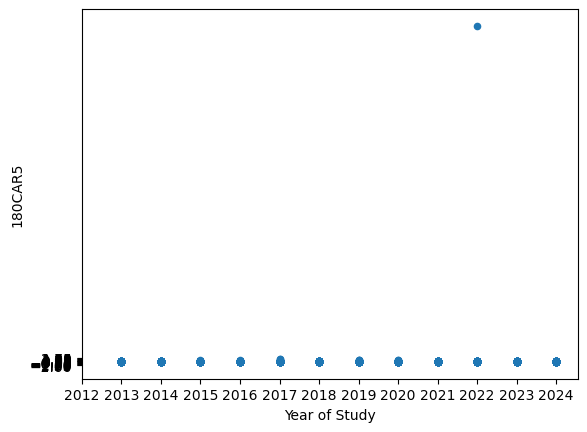

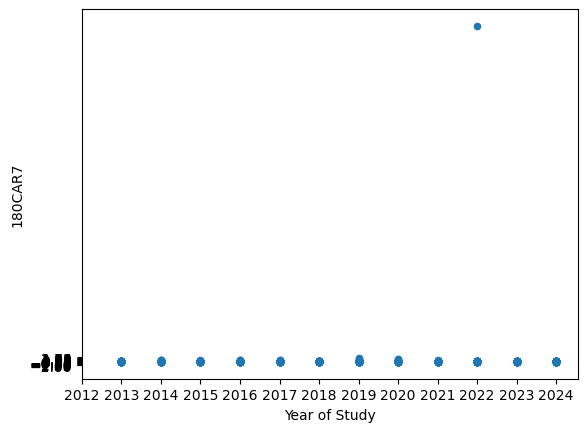

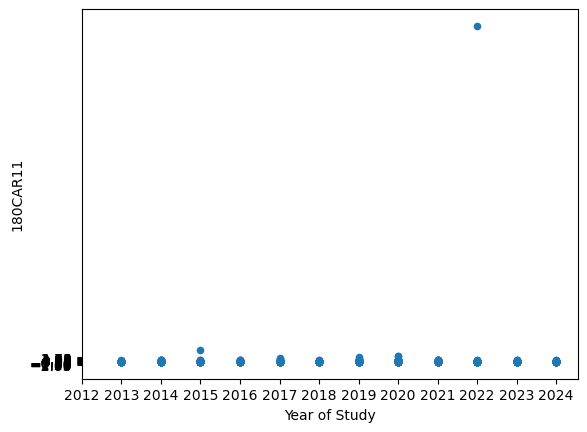

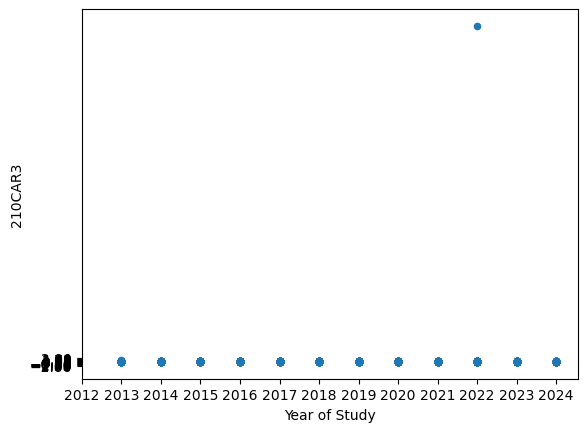

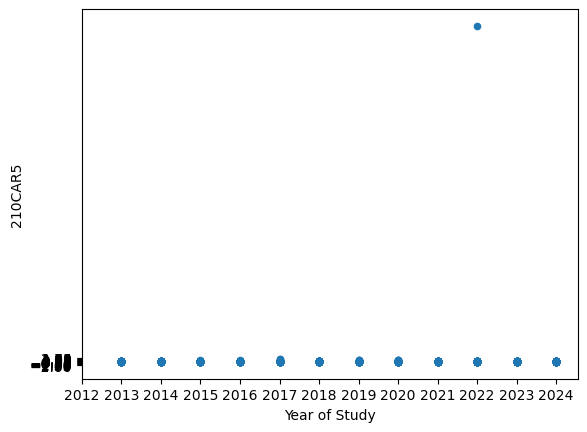

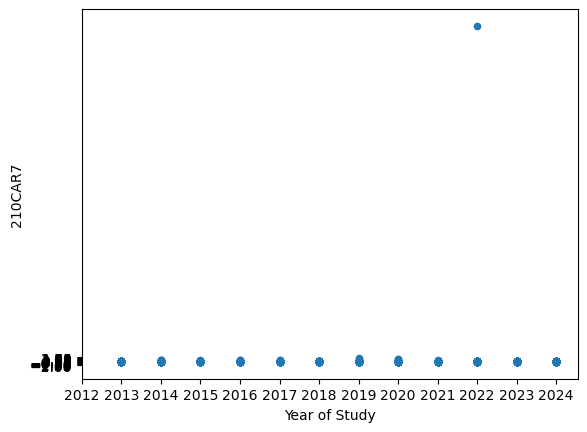

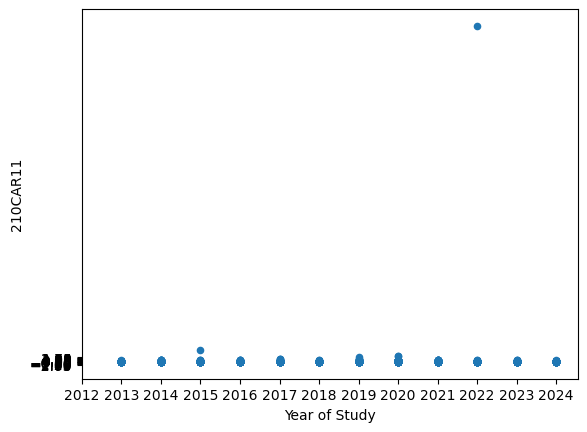

In [17]:
test = psmSampleIndep.copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [18]:
test.describe()

C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the Mask

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_SMB,OLS120_HML,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_SMB,OLS150_HML,OLS150_r_squared,OLS150_adjusted_r_squared,OLS15

### RID

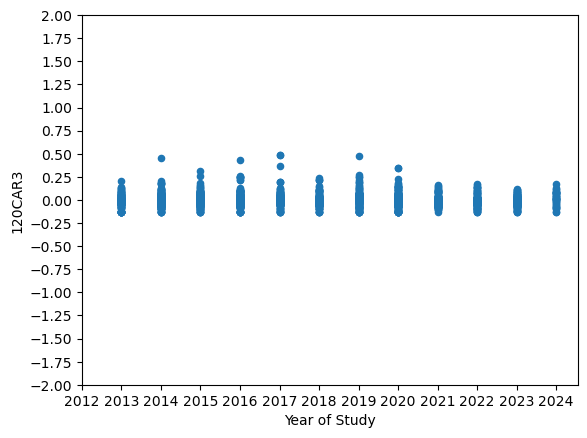

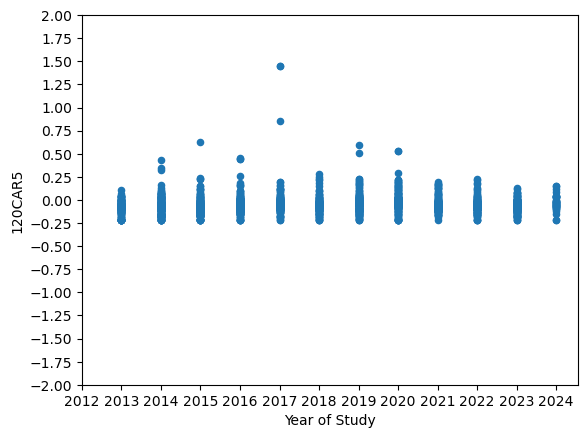

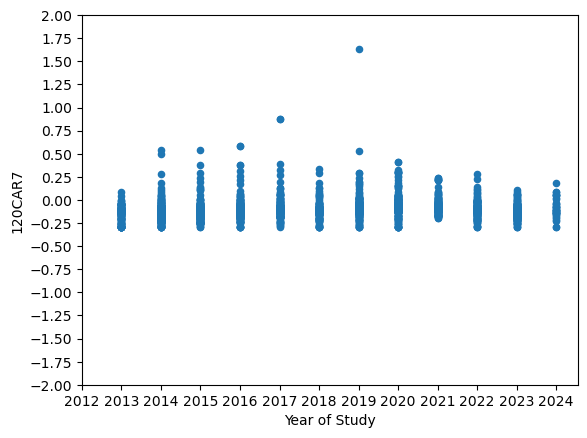

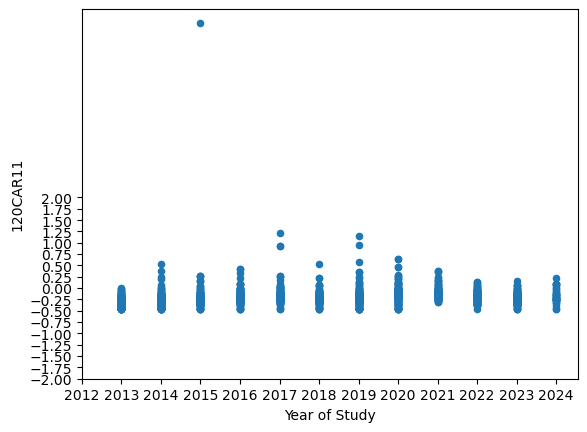

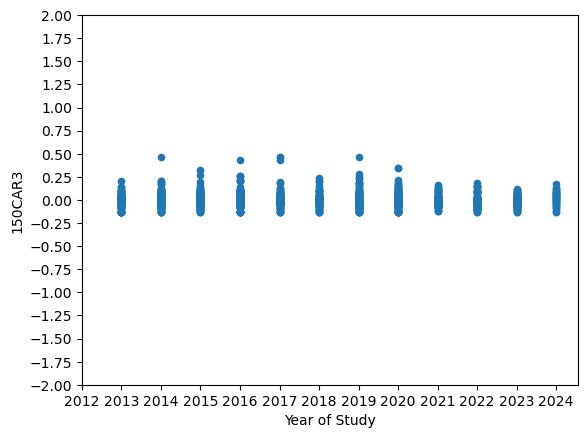

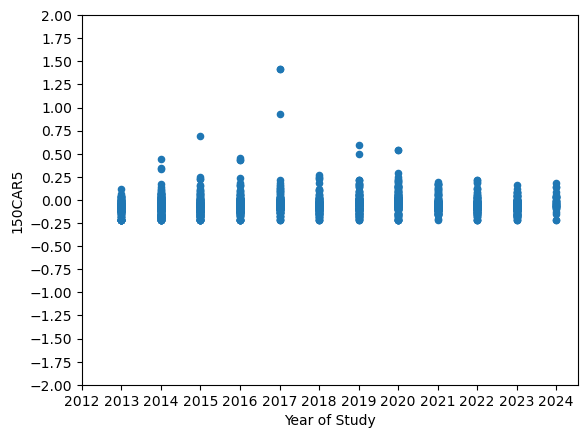

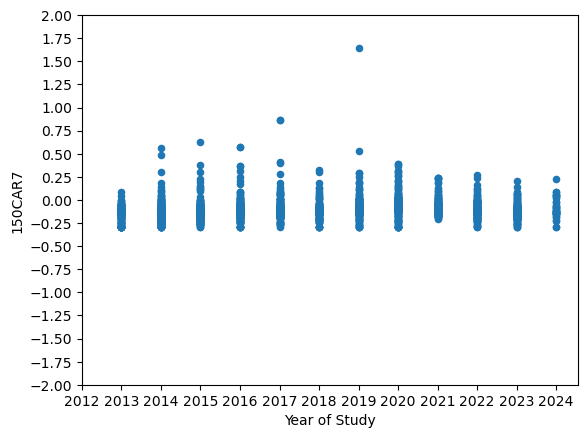

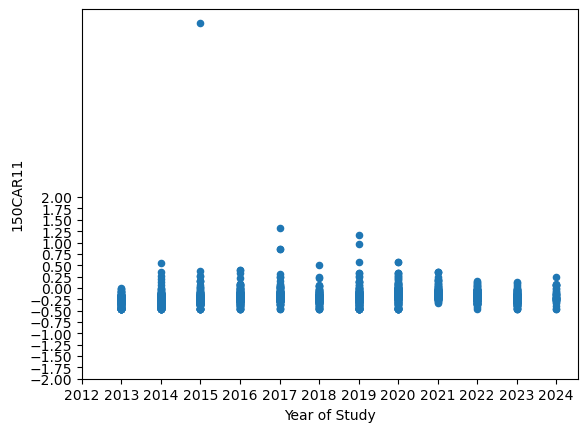

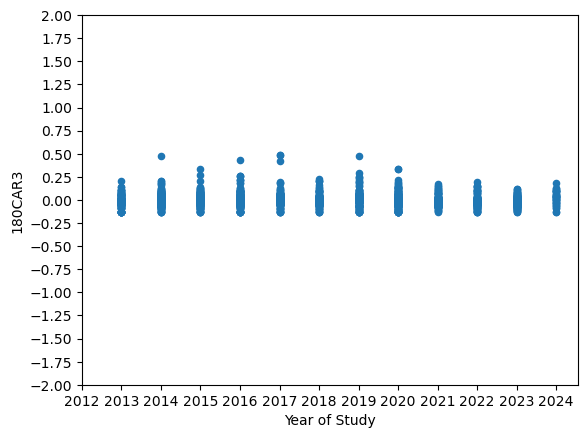

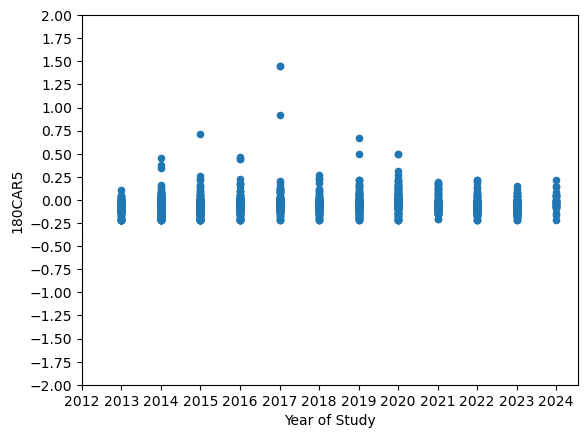

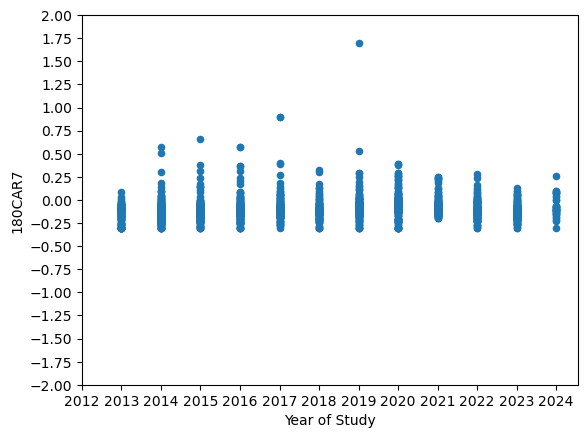

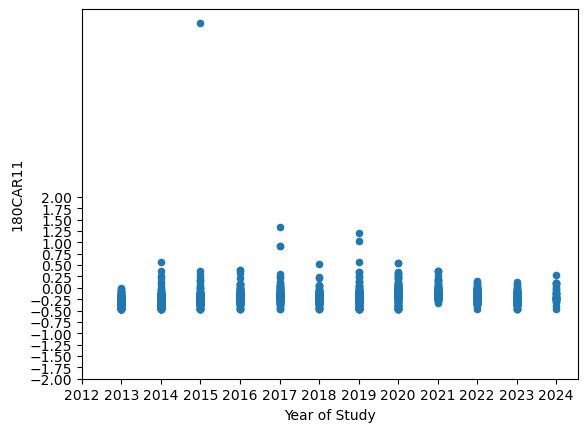

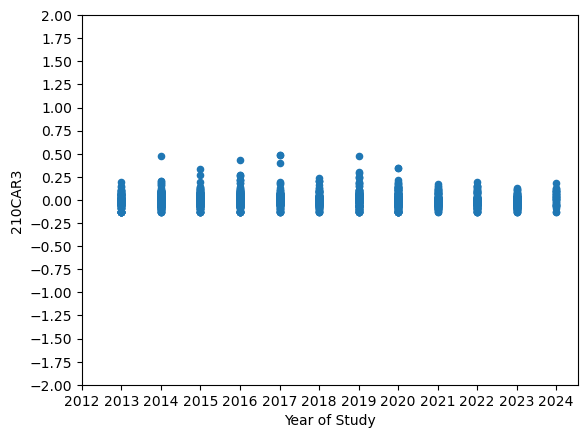

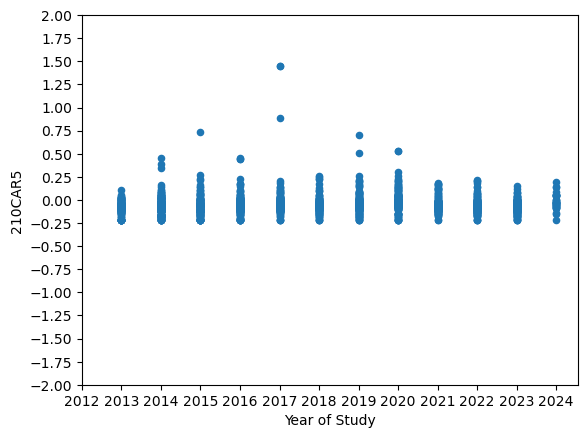

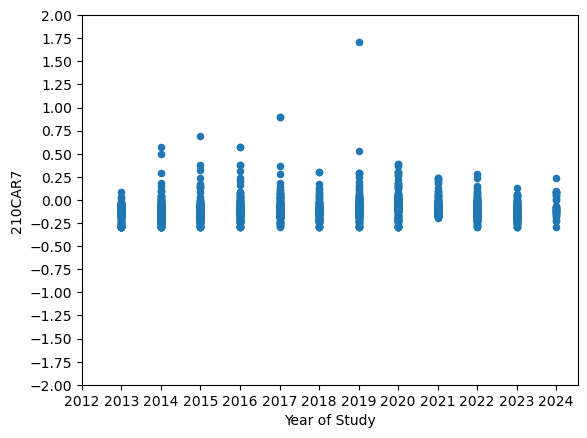

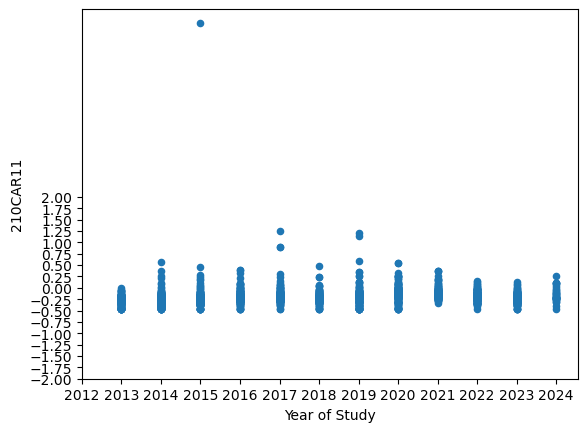

In [19]:
test = psmSampleIndep.loc[ psmSampleIndep["IsRookieIndep"] == 1 ].copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [20]:
test.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_SMB,OLS120_HML,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_SMB,OLS150_HML,OLS150_r_squared,OLS150_adjusted_r_squared,OLS15

In [21]:
test.loc[ test["120CAR5"] >= 0.75]

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

### Non RID

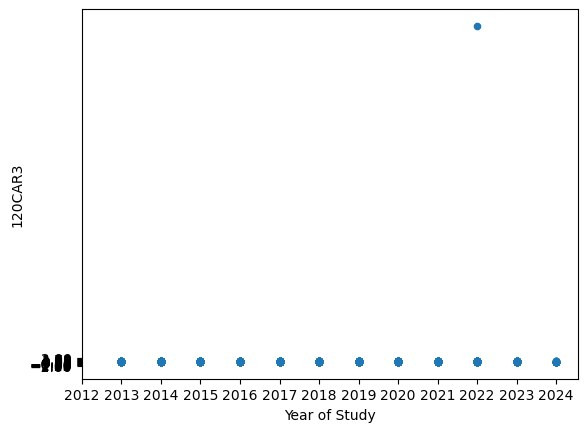

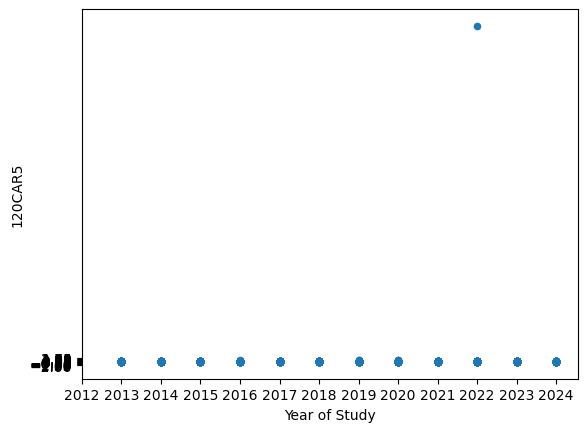

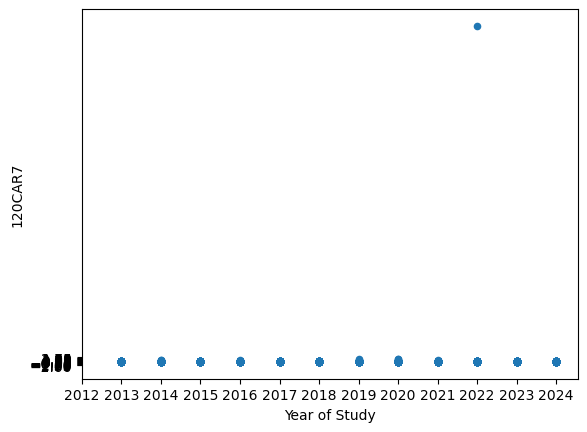

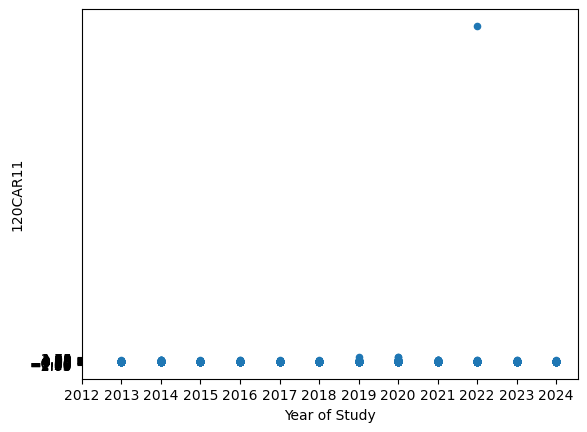

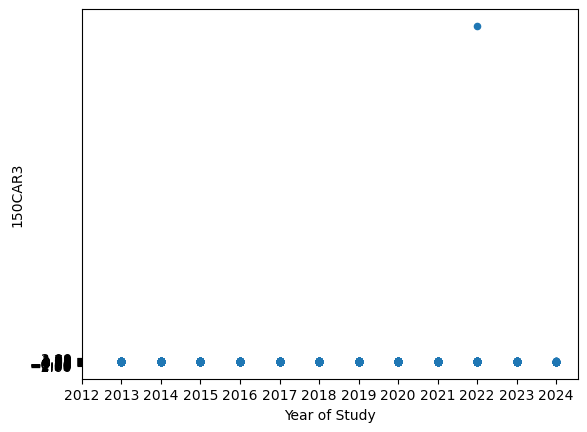

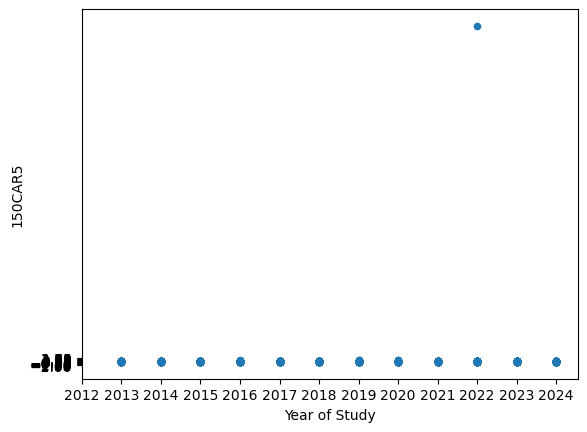

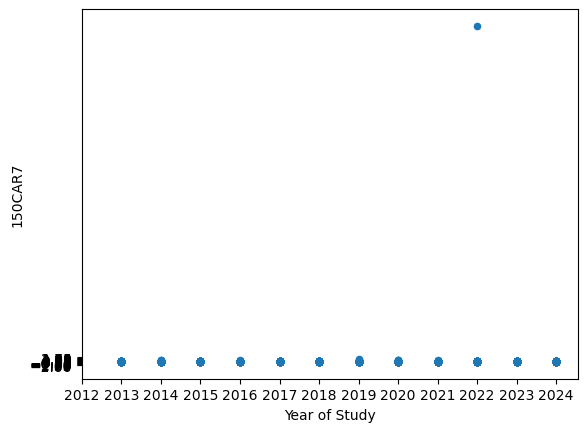

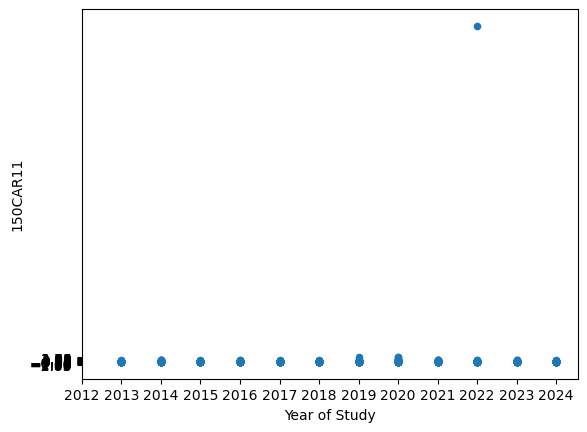

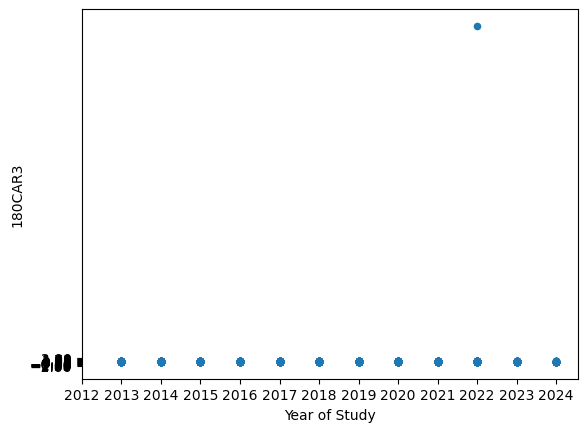

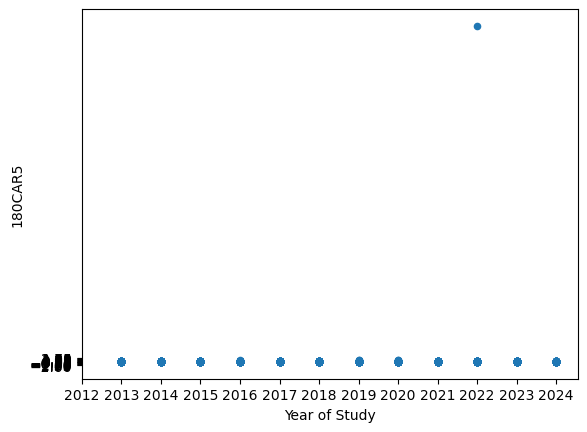

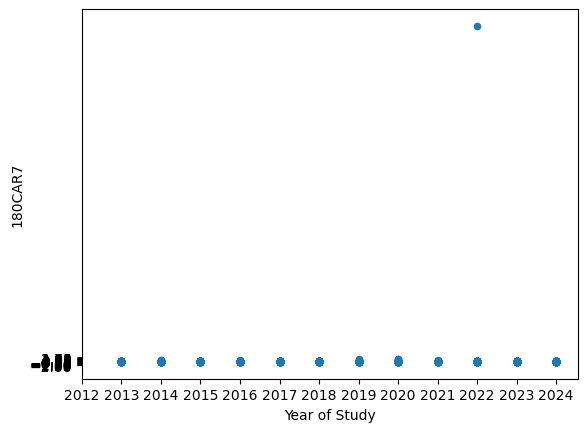

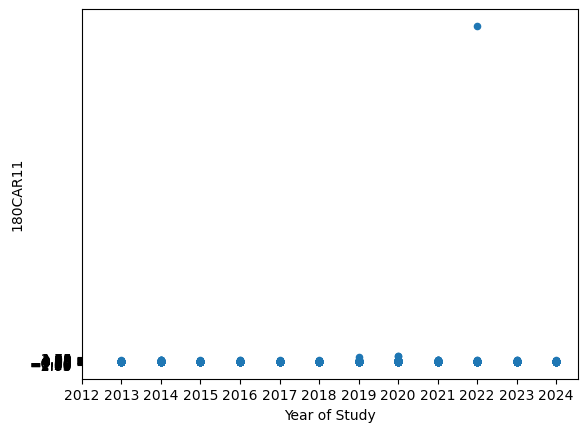

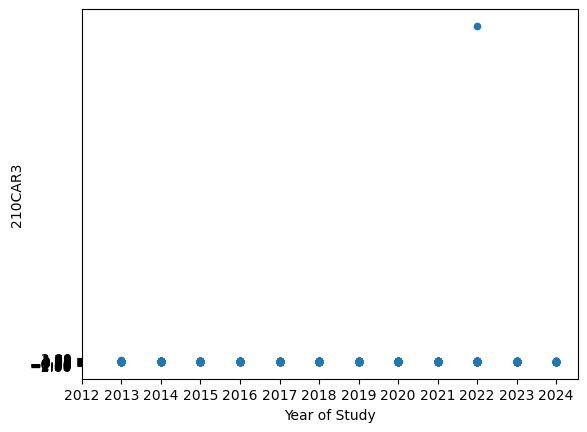

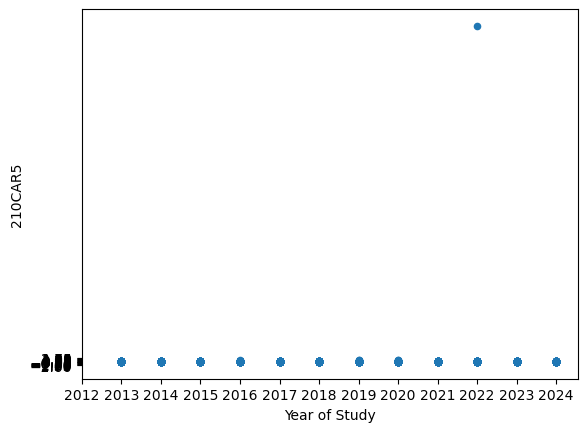

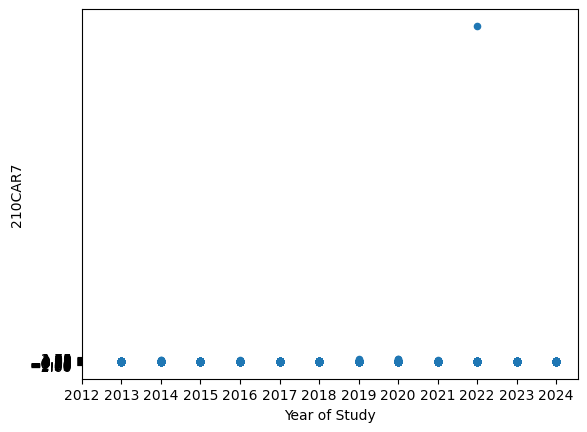

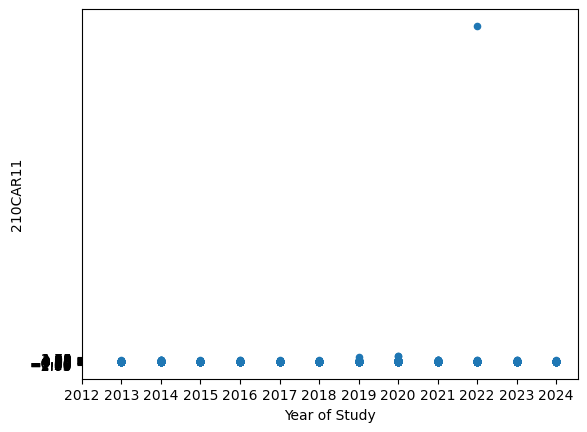

In [22]:
test = psmSampleIndep.loc[ psmSampleIndep["IsRookieIndep"] == 0 ].copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [23]:
test.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_SMB,OLS120_HML,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_SMB,OLS150_HML,OLS150_r_squared,OLS150_adjusted_r_squared,OLS15

In [24]:
test.loc[ test["180CAR11"] >= 2]

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

## Panel A: Whole Sample

### Mean Difference

In [25]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample = psmSampleIndep.dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)



120CAR3 :


T Statistic: 0.8681379359083877  P Value: 0.38538911975847834
Treated Mean: 5.895608328020628e-05  Control Mean: -0.0013569896924966699  Diff: 0.0014159457757768762
Treated Median: -0.005313346950420593  Control Median: -0.004627558395382224  Diff: -0.0006857885550383691
Treated N: 1920 ; Control N: 6134
[treated unique =  1920 ] [control unique =  6134 ]




120CAR5 :


T Statistic: -0.16955825605290278  P Value: 0.8653689823470616
Treated Mean: -0.050801916230270076  Control Mean: -0.05044397474093535  Diff: -0.000357941489334726
Treated Median: -0.054749312755711106  Control Median: -0.053818232979684244  Diff: -0.0009310797760268621
Treated N: 1920 ; Control N: 6134
[treated unique =  1920 ] [control unique =  6134 ]




120CAR7 :


T Statistic: -0.8146224982127115  P Value: 0.4153535698579284
Treated Mean: -0.1007208532141326  Control Mean: -0.09859413038133545  Diff: -0.0021267228327971482
Treated Median: -0.1070298031468391  Control Median: -0.10237052810112833  Di

In [26]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)

### One Sample T Test

In [27]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors:")
    sample = sample1.dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors:")
    sample = sample2.dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)


Rookie Independent Directors:


120CAR3 :


T Statistic: 0.36868599092987747  P Value: 0.7124024610211828
Mean: 0.0005503599686820623
Median: -0.005313346950420593
N: 1920


Non Rookie Independent Directors:


120CAR3 :


T Statistic: -1.9383191539757045  P Value: 0.05263012773954035
Mean: -0.0014204606987787969
Median: -0.004627558395382224
N: 6134


Rookie Independent Directors:


120CAR5 :


T Statistic: -26.710015437955775  P Value: 6.63904605763152e-134
Mean: -0.050586018522756446
Median: -0.054749312755711106
N: 1920


Non Rookie Independent Directors:


120CAR5 :


T Statistic: -52.66095470744798  P Value: 0.0
Mean: -0.050555379999948566
Median: -0.053818232979684244
N: 6134


Rookie Independent Directors:


120CAR7 :


T Statistic: -41.715505015583005  P Value: 3.457395341134818e-271
Mean: -0.09989164894527655
Median: -0.1070298031468391
N: 1918


Non Rookie Independent Directors:


120CAR7 :


T Statistic: -84.60083222120912  P Value: 0.0
Mean: -0.09893547455151352
Median: -0.

## Panel B: Unique skills dummy

### Mean Difference: RID vs NRID

In [28]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    print("No unique skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

No unique skills:


120CAR3 :


T Statistic: 1.1944997556995323  P Value: 0.2324670523876113
Treated Mean: 0.0031833109175958114  Control Mean: -0.0002592687705893613  Diff: 0.0034425796881851728
Treated Median: -0.0037151176515038548  Control Median: -0.004562147022030907  Diff: 0.0008470293705270526
Treated N: 832 ; Control N: 1673
[treated unique =  832 ] [control unique =  1673 ]


At least one unique skill:


120CAR3 :


T Statistic: 0.047578968336831666  P Value: 0.962057937674244
Treated Mean: -0.001648589022222181  Control Mean: -0.0017452747695763191  Diff: 9.668574735413821e-05
Treated Median: -0.006185818597992915  Control Median: -0.0046335087594484015  Diff: -0.0015523098385445133
Treated N: 1088 ; Control N: 4461
[treated unique =  1088 ] [control unique =  4461 ]


No unique skills:


120CAR5 :


T Statistic: 0.24728688887270997  P Value: 0.8047182686711327
Treated Mean: -0.05278020900700272  Control Mean: -0.053703499974161004  Diff: 0.0009232909671582842
Treated Median

### Mean Difference: within RID/NRID: WIP

In [29]:
# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# exog_var = None
# depVar = None
# controlVars = None

# for car in carCol:
#     print("No unique skills:")
#     sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
#     MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

#     print("At least one unique skill:")
#     sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
#     MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

### One Sample T Test

In [30]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors\nNo unique skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = sample1.loc[sample1["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors\nNo unique skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = sample2.loc[sample2["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Rookie Independent Directors
No unique skills:


120CAR3 :


T Statistic: 1.4352451237960926  P Value: 0.1515935201371771
Mean: 0.0035394897348195336
Median: -0.0037151176515038548
N: 832


At least one unique skill:


120CAR3 :


T Statistic: -0.8395913998542117  P Value: 0.40132213635404046
Mean: -0.0015648787276531509
Median: -0.006185818597992915
N: 1088


Non Rookie Independent Directors
No unique skills:


120CAR3 :


T Statistic: -0.35227943521112554  P Value: 0.7246731060862761
Mean: -0.0005418789170797133
Median: -0.004562147022030907
N: 1673


At least one unique skill:


120CAR3 :


T Statistic: -2.1215525534508117  P Value: 0.033930327600197645
Mean: -0.0017534687648024072
Median: -0.0046335087594484015
N: 4461


Rookie Independent Directors
No unique skills:


120CAR5 :


T Statistic: -14.675164840522514  P Value: 1.5845789242783467e-43
Mean: -0.050516738052130195
Median: -0.05730879070292611
N: 832


At least one unique skill:


120CAR5 :


T Statistic: -20.12641494785514

In [31]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)

## Panel C: Number of Skills

### Mean Difference

In [32]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

num_skills_median = psmSampleIndep.drop_duplicates(subset = ["AsOnDate", "Person Code"])["NumSkills_gai"].median()
for car in carCol:
    print("Less than median no. skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Less than median no. skills:


120CAR3 :


T Statistic: 0.6295980489404048  P Value: 0.5290151226162338
Treated Mean: 0.0003479466571118376  Control Mean: -0.000952302849852685  Diff: 0.0013002495069645227
Treated Median: -0.005336420639263251  Control Median: -0.004713786188933818  Diff: -0.0006226344503294338
Treated N: 1424 ; Control N: 3251
[treated unique =  1424 ] [control unique =  3251 ]


Greater than median no. skills:


120CAR3 :


T Statistic: 0.8938114628830006  P Value: 0.37180506996279106
Treated Mean: 0.0007809463753139706  Control Mean: -0.0018600681510181163  Diff: 0.002641014526332087
Treated Median: -0.0031257619684571664  Control Median: -0.004445404158573247  Diff: 0.0013196421901160802
Treated N: 437 ; Control N: 2734
[treated unique =  437 ] [control unique =  2734 ]


Less than median no. skills:


120CAR5 :


T Statistic: -0.16596234888878011  P Value: 0.8681997395487849
Treated Mean: -0.05333362820624716  Control Mean: -0.052892740101092746  Diff: -0.00044088

### One Sample T Test

In [33]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

num_skills_median = psmSampleIndep.drop_duplicates(subset = ["AsOnDate", "Person Code"])["NumSkills_gai"].median()
for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors\nLess than median no. skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors\nLess than median no. skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Rookie Independent Directors
Less than median no. skills:


120CAR3 :


T Statistic: 0.41253004322325953  P Value: 0.6800131069201012
Mean: 0.0007443340294265385
Median: -0.005336420639263251
N: 1424


Greater than median no. skills:


120CAR3 :


T Statistic: 0.41253004322325953  P Value: 0.6800131069201012
Mean: 0.0007443340294265385
Median: -0.005336420639263251
N: 1424


Non Rookie Independent Directors
Less than median no. skills:


120CAR3 :


T Statistic: -1.8106527012288585  P Value: 0.07030439565034435
Mean: -0.0018600681510181163
Median: -0.004445404158573247
N: 2734


Greater than median no. skills:


120CAR3 :


T Statistic: -1.8106527012288585  P Value: 0.07030439565034435
Mean: -0.0018600681510181163
Median: -0.004445404158573247
N: 2734


Rookie Independent Directors
Less than median no. skills:


120CAR5 :


T Statistic: -22.83022243205054  P Value: 1.490649089224864e-98
Mean: -0.0527903537933114
Median: -0.05711376668319361
N: 1424


Greater than median no. skills:


1

In [34]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)